HYBRID ENERGY GENERATION SYSTEM - DAILY SUMMARY

Daily Energy Generated by Technology:
  Perovskite Solar Panel: 49.8685 kWh (49868.55 Wh)
  Air-Gen (Humidity):     24.7104 kWh (24710.40 Wh)
  Thermoelectric (TEG):   9.7443 kWh (9744.29 Wh)
  ────────────────────────────────────────────────────────
  TOTAL:                  84.3232 kWh (84323.24 Wh)

WASTE HEAT SOURCES & THERMOELECTRIC CONVERSION

Waste Heat Available (Input to TEG):
  Household Waste Heat:        25.0000 kWh/day
  Perovskite Solar Panel Waste: 0.0968 kWh/day
  ────────────────────────────────────────────────────────
  TOTAL Waste Heat Available:  25.0968 kWh/day

Thermoelectric Electrical Output (@ 8% efficiency):
  From Household Waste Heat:   2.0000 kWh/day
  From PV Panel Waste Heat:    0.0077 kWh/day
  ────────────────────────────────────────────────────────
  Total TEG Output:            9.7443 kWh/day

PV Waste Heat Efficiency Improvement:
  PV Panel Waste Heat increases TEG output by: 0.4%

HOURLY POWER GENERAT

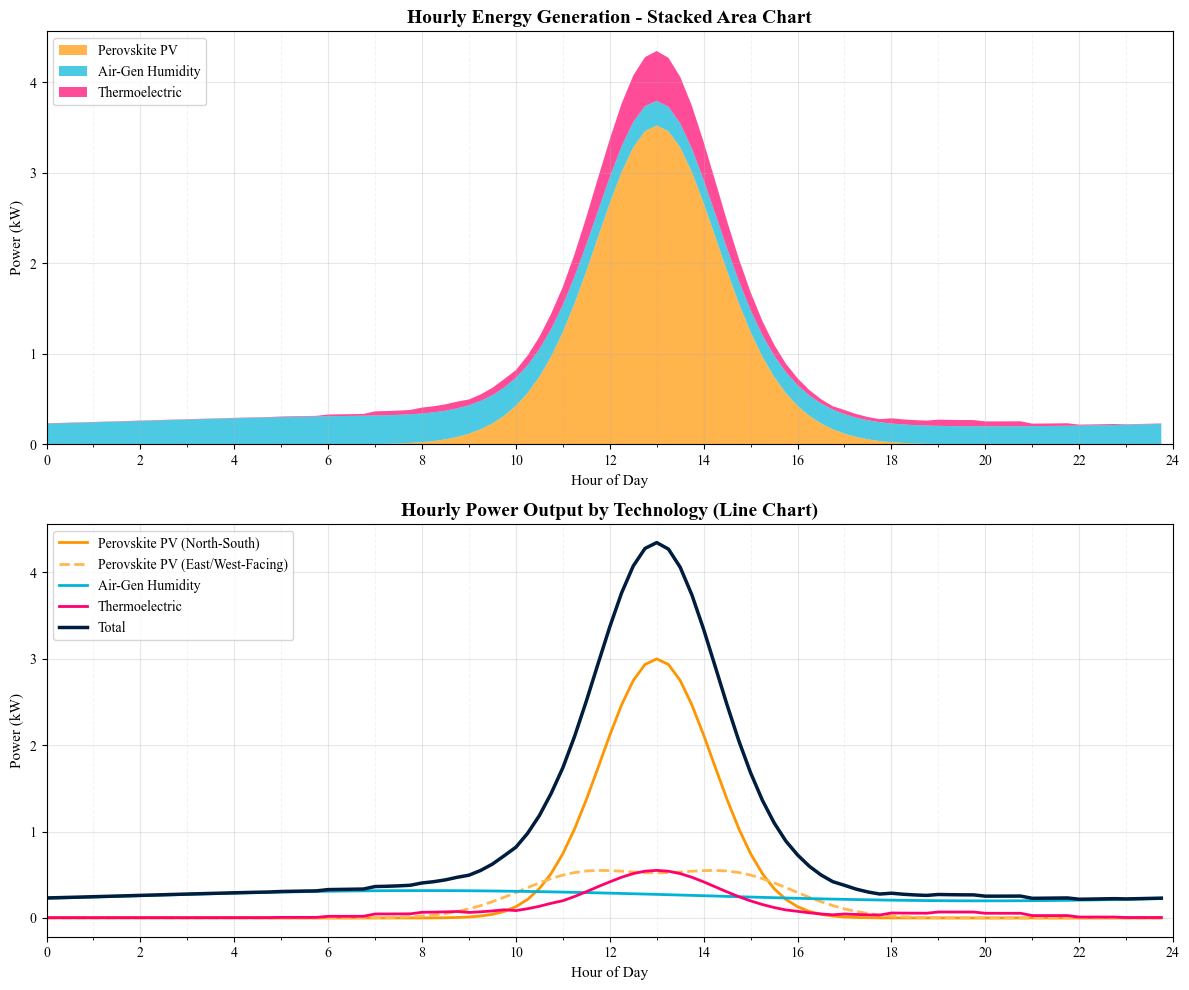

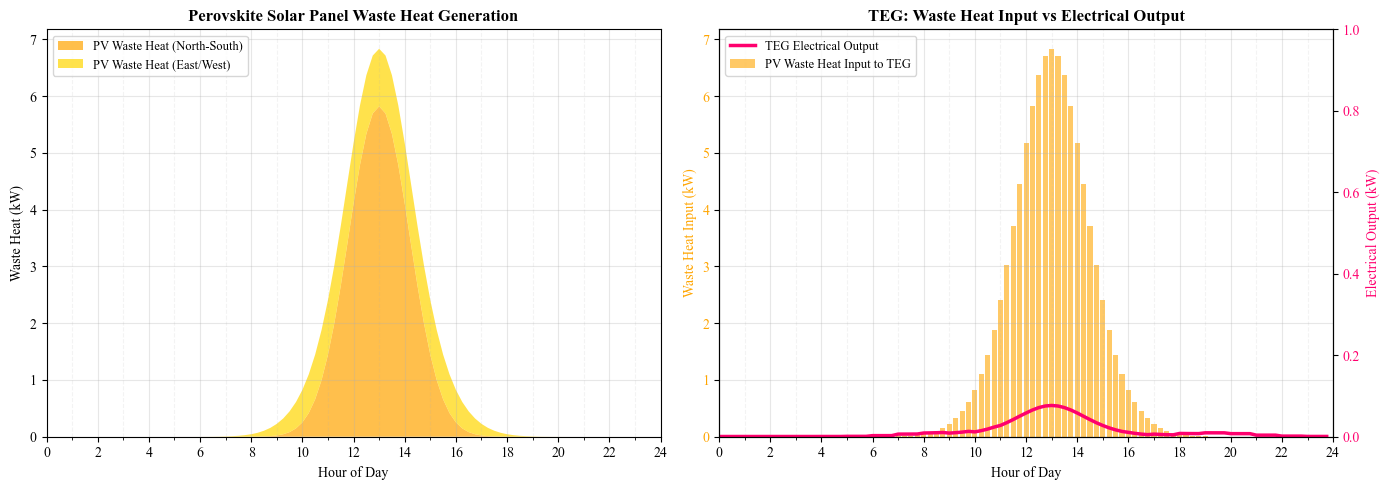

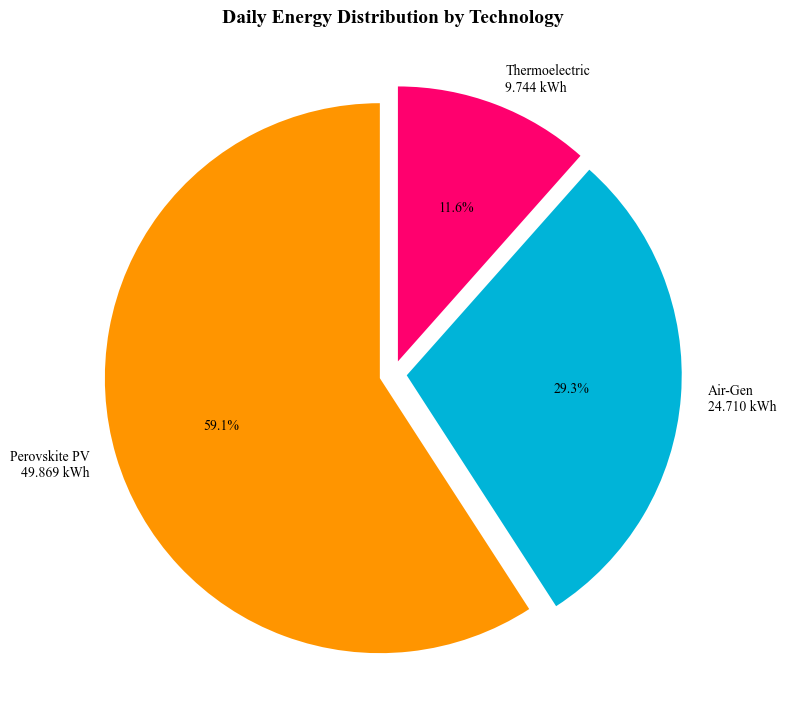


ENERGY GENERATION vs HOUSEHOLD CONSUMPTION SCENARIOS
Total Daily Generation:    84.3232 kWh

25 kWh (Small)             25.00 kWh  →  Surplus: 59.3232 kWh ✓
35 kWh (Regular)           35.00 kWh  →  Surplus: 49.3232 kWh ✓
45 kWh (Large)             45.00 kWh  →  Surplus: 39.3232 kWh ✓
60 kWh (Emergency)         60.00 kWh  →  Surplus: 24.3232 kWh ✓


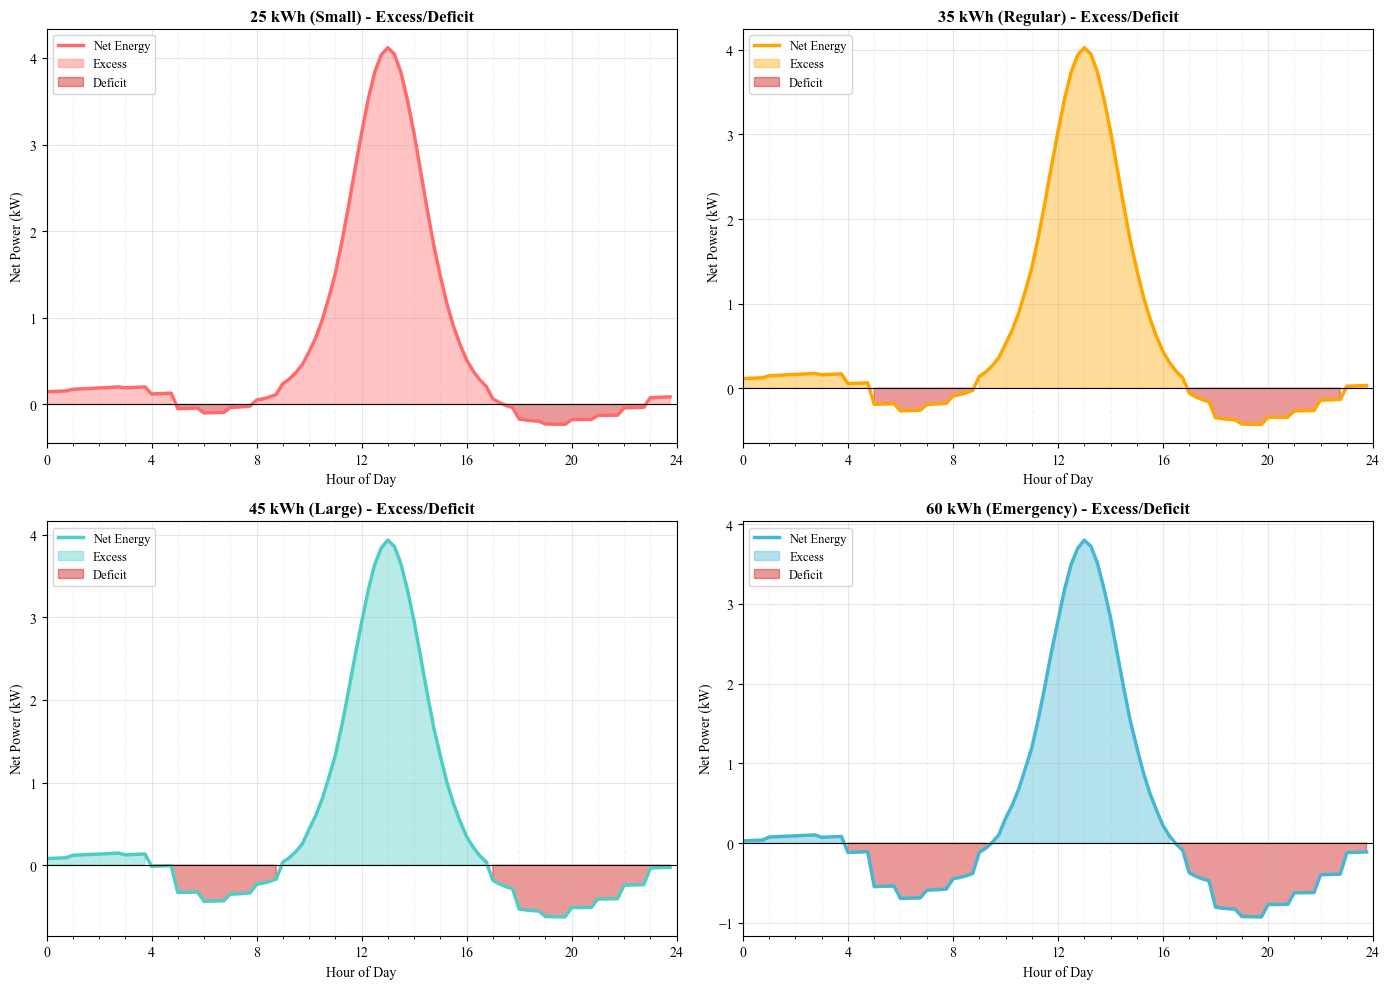

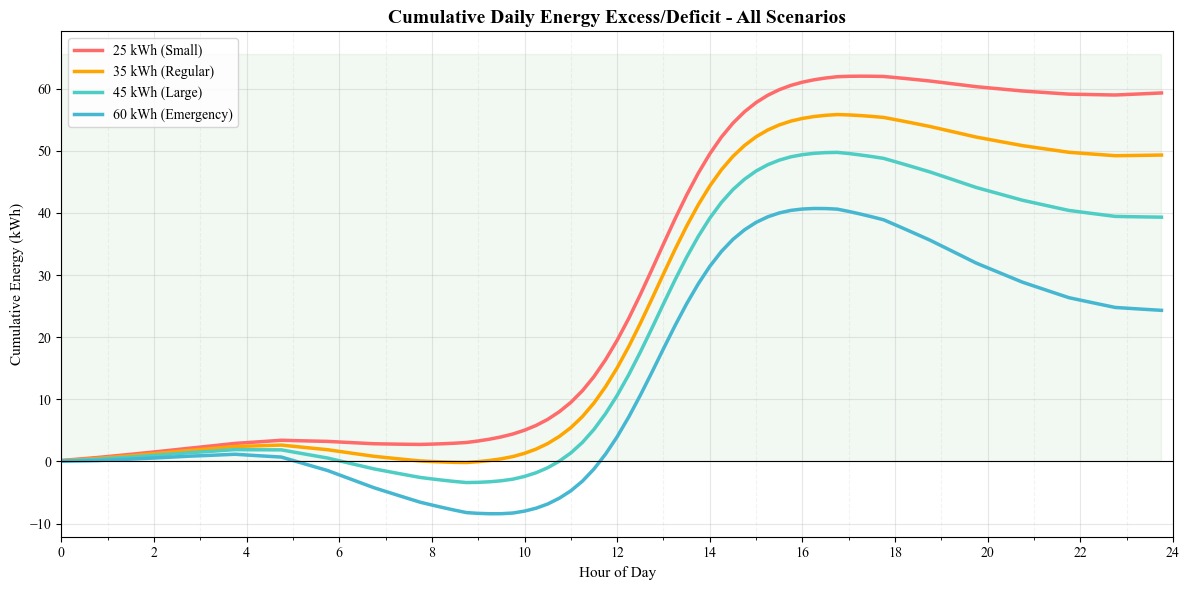

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
from pvlib.location import Location
from pvlib.modelchain import ModelChain
from pvlib.pvsystem import PVSystem
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

# 1. Define device parameters (simplified assumptions)
# Perovskite - Split equally between two roof orientations
# North-South roof (50% of area)
PEROVSKITE_EFFICIENCY = 0.34  # 34% efficiency
PV_AREA_NORTH_SOUTH = 18.00   # 50% of area on north-south roof (m^2)
PV_AREA_EAST_WEST = 18.00     #6 50% of area on east/west-facing roof (m^2)
PV_AREA_TOTAL = PV_AREA_NORTH_SOUTH + PV_AREA_EAST_WEST  # Total area in m^2

# Air-Gen (humidity-based power generation, higher efficiency at night with higher RH)
AIRGEN_EFFICIENCY = 11.0       # W/m² at reference humidity level
AIRGEN_AREA = 36.0            # Area in m^2

# Thermoelectric Generator (TEG) (converts waste heat from house)
# Waste heat input: 25 kWh/day, peaks during morning and evening usage
# Converts at 12% efficiency (no area - just waste heat from HVAC, appliances, etc.)
TEG_EFFICIENCY = 0.08           # 12% conversion efficiency

# 2. Get Weather Data (Example: Create realistic simulated data)
# Create 15-minute interval data for a full day
hours = np.arange(0, 24, 0.25)
dates = pd.date_range(start='2026-01-06', periods=len(hours), freq='15min')

weather_df = pd.DataFrame({
    'ghi': 0.7 * 700 * np.exp(-((hours - 13)**2) / 5.5),  # Bell curve: power < 350W at 6am and 5:30pm
    'dhi': 0.7 * 210 * np.exp(-((hours - 13)**2) / 6),  # Diffuse component
    'dni': 0.7 * 560 * np.exp(-((hours - 13)**2) / 5),  # Direct component
    'temp_air': 20 + 10 * np.sin(np.pi * (hours - 8) / 12),  # Temperature variation
    'relative_humidity': 65 + 15 * np.sin(np.pi * (hours - 2) / 12)  # Higher humidity at night (peaks around 2am)
})
weather_df.index = dates
weather_df.index.name = 'Datetime'

# Add hour column for better readability
weather_df['Hour'] = weather_df.index.hour
weather_df['Hour_continuous'] = hours  # 0-24 with 0.25 step for 15-minute intervals

# 3. Component Power Modeling Functions

def calculate_pv_power(ghi, efficiency, area):
    """Simplified PV power calculation: Power = Irradiance * Efficiency * Area (W)"""
    return ghi * efficiency * area

def calculate_airgen_power(humidity, efficiency, area):
    """
    Air-Gen model: Power output scales with humidity level.
    Higher efficiency at night due to increased relative humidity.
    Power = Efficiency (W/m²) × Area (m²) × (Humidity / 100)
    """
    power_output = efficiency * area * (humidity / 100.0)
    return power_output.clip(lower=0)  # Power cannot be negative

def calculate_teg_power(hours, efficiency, pv_waste_heat_kw=None):
    """
    TEG model: Converts waste heat from house AND solar panels at given efficiency.
    
    Waste heat sources:
    1. Household waste heat: peaks during morning (6-10am) and evening (5-11pm) peak usage
    2. Perovskite solar panel waste heat: proportional to solar irradiance absorbed
       (waste heat = irradiance × area × (1 - PV efficiency))
    
    Total conversion at 12% efficiency
    """
    # Model house waste heat pattern: peaks during morning and evening usage
    # Morning peak: 6-10am (heating, showers), Evening peak: 5-11pm (cooking, heating)
    morning_peak = 4.5 * np.exp(-((hours - 8)**2) / 3)  # Peak at 8am
    evening_peak = 5.0 * np.exp(-((hours - 19)**2) / 4)  # Peak at 7pm
    idle_baseline = 0.3  # Baseline waste heat at night
    
    # Combined household waste heat input (kW)
    household_waste_heat_kw = morning_peak + evening_peak + idle_baseline
    
    # Normalize household waste heat to ~25 kWh/day total (sum over 24 hours ≈ 25)
    household_waste_heat_kw = household_waste_heat_kw * (25.0 / household_waste_heat_kw.sum())
    
    # Total waste heat = household waste heat + perovskite solar panel waste heat
    if pv_waste_heat_kw is not None:
        total_waste_heat_kw = household_waste_heat_kw + pv_waste_heat_kw
    else:
        total_waste_heat_kw = household_waste_heat_kw
    
    # Convert to electrical power output (W)
    power_output = total_waste_heat_kw * efficiency * 1000
    
    return power_output

# 4. Simulation Execution

# Calculate PV power for both roof orientations
# North-South: optimal around solar noon (13:00)
north_south_facing_orientation = np.exp(-((hours - 13)**2) / 6)  # Tighter bell curve around noon

# East/West-facing: gets sun throughout most of the day, not sharp peaks
# Much wider gaussian curves (σ=12) to represent roof that catches sun all day
# East-facing: peaks at 8am but stays productive until ~3pm
# West-facing: peaks at 6pm but stays productive from ~9am onward
# Combined, they provide consistent power throughout the solar day
east_facing_orientation = 0.7 * np.exp(-((hours - 8)**2) / 12)   # Morning to afternoon
west_facing_orientation = 0.7 * np.exp(-((hours - 18)**2) / 12)  # Midday to evening
east_west_combined = east_facing_orientation + west_facing_orientation
# Note: NOT normalized - preserves 0.7x efficiency factor for oblique angles
# At solar noon (13:00): both contribute: east ≈0.59, west ≈0.59, combined ≈1.18 (but capped at peak)

weather_df['P_PV_NorthSouth'] = calculate_pv_power(weather_df['ghi'] * north_south_facing_orientation, PEROVSKITE_EFFICIENCY, PV_AREA_NORTH_SOUTH)
weather_df['P_PV_EastWest'] = calculate_pv_power(weather_df['ghi'] * east_west_combined, PEROVSKITE_EFFICIENCY, PV_AREA_EAST_WEST)
weather_df['P_PV'] = weather_df['P_PV_NorthSouth'] + weather_df['P_PV_EastWest']

# Calculate perovskite waste heat (irradiance × area × (1 - efficiency))
# North-South waste heat
pv_waste_heat_north_south_kw = (weather_df['ghi'] * north_south_facing_orientation * PV_AREA_NORTH_SOUTH * (1 - PEROVSKITE_EFFICIENCY) / 1000.0)
# East/West-facing waste heat
pv_waste_heat_eastweast_kw = (weather_df['ghi'] * east_west_combined * PV_AREA_EAST_WEST * (1 - PEROVSKITE_EFFICIENCY) / 1000.0)
# Total perovskite waste heat (kW)
pv_waste_heat_total_kw = pv_waste_heat_north_south_kw + pv_waste_heat_eastweast_kw

weather_df['P_AirGen'] = calculate_airgen_power(weather_df['relative_humidity'], AIRGEN_EFFICIENCY, AIRGEN_AREA)
weather_df['P_TEG'] = calculate_teg_power(weather_df['Hour'].values, TEG_EFFICIENCY, pv_waste_heat_total_kw.values)
weather_df['P_Total'] = weather_df['P_PV'] + weather_df['P_AirGen'] + weather_df['P_TEG']

# 5. Energy Calculation (Integration over time)
daily_energy_pv_Wh = weather_df['P_PV'].sum()
daily_energy_airgen_Wh = weather_df['P_AirGen'].sum()
daily_energy_teg_Wh = weather_df['P_TEG'].sum()
daily_energy_total_Wh = weather_df['P_Total'].sum()

daily_energy_pv_kWh = daily_energy_pv_Wh / 1000.0
daily_energy_airgen_kWh = daily_energy_airgen_Wh / 1000.0
daily_energy_teg_kWh = daily_energy_teg_Wh / 1000.0
daily_energy_total_kWh = daily_energy_total_Wh / 1000.0

print("=" * 60)
print("HYBRID ENERGY GENERATION SYSTEM - DAILY SUMMARY")
print("=" * 60)
print(f"\nDaily Energy Generated by Technology:")
print(f"  Perovskite Solar Panel: {daily_energy_pv_kWh:.4f} kWh ({daily_energy_pv_Wh:.2f} Wh)")
print(f"  Air-Gen (Humidity):     {daily_energy_airgen_kWh:.4f} kWh ({daily_energy_airgen_Wh:.2f} Wh)")
print(f"  Thermoelectric (TEG):   {daily_energy_teg_kWh:.4f} kWh ({daily_energy_teg_Wh:.2f} Wh)")
print(f"  {'─' * 56}")
print(f"  TOTAL:                  {daily_energy_total_kWh:.4f} kWh ({daily_energy_total_Wh:.2f} Wh)")
print("=" * 60)

# Calculate waste heat totals
daily_household_waste_heat_kWh = 25.0  # Fixed household waste heat
daily_pv_waste_heat_Wh = pv_waste_heat_total_kw.sum()  # Sum of all 15-min intervals
daily_pv_waste_heat_kWh = daily_pv_waste_heat_Wh / 1000.0
total_waste_heat_available_kWh = daily_household_waste_heat_kWh + daily_pv_waste_heat_kWh
teg_electrical_from_household_kWh = daily_household_waste_heat_kWh * TEG_EFFICIENCY
teg_electrical_from_pv_waste_kWh = daily_pv_waste_heat_kWh * TEG_EFFICIENCY

print("\n" + "=" * 60)
print("WASTE HEAT SOURCES & THERMOELECTRIC CONVERSION")
print("=" * 60)
print(f"\nWaste Heat Available (Input to TEG):")
print(f"  Household Waste Heat:        {daily_household_waste_heat_kWh:.4f} kWh/day")
print(f"  Perovskite Solar Panel Waste: {daily_pv_waste_heat_kWh:.4f} kWh/day")
print(f"  {'─' * 56}")
print(f"  TOTAL Waste Heat Available:  {total_waste_heat_available_kWh:.4f} kWh/day")
print(f"\nThermoelectric Electrical Output (@ {TEG_EFFICIENCY*100:.0f}% efficiency):")
print(f"  From Household Waste Heat:   {teg_electrical_from_household_kWh:.4f} kWh/day")
print(f"  From PV Panel Waste Heat:    {teg_electrical_from_pv_waste_kWh:.4f} kWh/day")
print(f"  {'─' * 56}")
print(f"  Total TEG Output:            {daily_energy_teg_kWh:.4f} kWh/day")
print(f"\nPV Waste Heat Efficiency Improvement:")
print(f"  PV Panel Waste Heat increases TEG output by: {(teg_electrical_from_pv_waste_kWh/teg_electrical_from_household_kWh)*100:.1f}%")
print("=" * 60)

print("\n" + "=" * 60)
print("HOURLY POWER GENERATION (kW) - By Technology and Time")
print("=" * 60)

# Create a display dataframe with hour and all power values (converted to kW)
display_df = weather_df[['Hour', 'P_PV', 'P_AirGen', 'P_TEG', 'P_Total']].copy()
display_df.columns = ['Hour', 'Perovskite (kW)', 'Air-Gen (kW)', 'TEG (kW)', 'Total (kW)']
display_df['Hour'] = display_df['Hour'].astype(int).apply(lambda x: f"{x:02d}:00")
for col in ['Perovskite (kW)', 'Air-Gen (kW)', 'TEG (kW)', 'Total (kW)']:
    display_df[col] = (display_df[col] / 1000.0).round(3)
print(display_df.to_string(index=False))

print("\n" + "=" * 60)
print("PEAK POWER GENERATION BY TECHNOLOGY")
print("=" * 60)
peak_pv_idx = weather_df['P_PV'].idxmax()
peak_pv_hour = weather_df.loc[peak_pv_idx, 'Hour']
peak_pv_power = weather_df.loc[peak_pv_idx, 'P_PV']

peak_airgen_idx = weather_df['P_AirGen'].idxmax()
peak_airgen_hour = weather_df.loc[peak_airgen_idx, 'Hour']
peak_airgen_power = weather_df.loc[peak_airgen_idx, 'P_AirGen']

peak_teg_idx = weather_df['P_TEG'].idxmax()
peak_teg_hour = weather_df.loc[peak_teg_idx, 'Hour']
peak_teg_power = weather_df.loc[peak_teg_idx, 'P_TEG']

peak_total_idx = weather_df['P_Total'].idxmax()
peak_total_hour = weather_df.loc[peak_total_idx, 'Hour']
peak_total_power = weather_df.loc[peak_total_idx, 'P_Total']

print(f"  Perovskite Solar Panel: {peak_pv_power:.2f} W at {int(peak_pv_hour):02d}:00")
print(f"  Air-Gen (Humidity):     {peak_airgen_power:.2f} W at {int(peak_airgen_hour):02d}:00")
print(f"  Thermoelectric (TEG):   {peak_teg_power:.2f} W at {int(peak_teg_hour):02d}:00")
print(f"  TOTAL SYSTEM:           {peak_total_power:.2f} W at {int(peak_total_hour):02d}:00")
print("=" * 60)

# 6. Visualization - Stacked Area Chart
plt.rcParams['font.family'] = 'Times New Roman'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Stacked area chart
ax1.stackplot(weather_df['Hour_continuous'], weather_df['P_PV']/1000, weather_df['P_AirGen']/1000, weather_df['P_TEG']/1000,
              labels=['Perovskite PV', 'Air-Gen Humidity', 'Thermoelectric'],
              colors=['#FF9500', '#00B4D8', '#FF006E'], alpha=0.7)
ax1.set_title('Hourly Energy Generation - Stacked Area Chart', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Power (kW)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3, which='major')
ax1.grid(True, alpha=0.15, which='minor', linestyle='--')
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 2))
ax1.set_xticks(range(0, 25, 1), minor=True)

# Individual line chart for comparison
ax2.plot(weather_df['Hour_continuous'], weather_df['P_PV_NorthSouth']/1000, marker='', linewidth=2, label='Perovskite PV (North-South)', color='#FF9500', linestyle='-')
ax2.plot(weather_df['Hour_continuous'], weather_df['P_PV_EastWest']/1000, marker='', linewidth=2, label='Perovskite PV (East/West-Facing)', color='#FFB84D', linestyle='--')
ax2.plot(weather_df['Hour_continuous'], weather_df['P_AirGen']/1000, marker='', linewidth=2, label='Air-Gen Humidity', color='#00B4D8')
ax2.plot(weather_df['Hour_continuous'], weather_df['P_TEG']/1000, marker='', linewidth=2, label='Thermoelectric', color='#FF006E')
ax2.plot(weather_df['Hour_continuous'], weather_df['P_Total']/1000, marker='', linewidth=2.5, label='Total', color='#001D3D')
ax2.set_title('Hourly Power Output by Technology (Line Chart)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hour of Day', fontsize=11)
ax2.set_ylabel('Power (kW)', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3, which='major')
ax2.grid(True, alpha=0.15, which='minor', linestyle='--')
ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 2))
ax2.set_xticks(range(0, 25, 1), minor=True)

plt.tight_layout()
plt.show()

# 7. Waste Heat Analysis Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Waste heat sources over time (stacked area)
ax1.stackplot(weather_df['Hour_continuous'], 
              pv_waste_heat_north_south_kw, pv_waste_heat_eastweast_kw,
              labels=['PV Waste Heat (North-South)', 'PV Waste Heat (East/West)'],
              colors=['#FFA500', '#FFD700'], alpha=0.7)
ax1.set_title('Perovskite Solar Panel Waste Heat Generation', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hour of Day', fontsize=10)
ax1.set_ylabel('Waste Heat (kW)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3, which='major')
ax1.grid(True, alpha=0.15, which='minor', linestyle='--')
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 2))
ax1.set_xticks(range(0, 25, 1), minor=True)

# TEG input sources (household vs PV waste heat) and TEG output
ax2_twin = ax2.twinx()

ax2.bar(weather_df['Hour_continuous'], pv_waste_heat_total_kw, width=0.2, 
        alpha=0.6, color='#FFA500', label='PV Waste Heat Input to TEG')
ax2.plot(weather_df['Hour_continuous'], weather_df['P_TEG']/1000, marker='', linewidth=2.5, 
         color='#FF006E', label='TEG Electrical Output', linestyle='-')

ax2.set_title('TEG: Waste Heat Input vs Electrical Output', fontsize=12, fontweight='bold')
ax2.set_xlabel('Hour of Day', fontsize=10)
ax2.set_ylabel('Waste Heat Input (kW)', fontsize=10, color='#FFA500')
ax2_twin.set_ylabel('Electrical Output (kW)', fontsize=10, color='#FF006E')
ax2.tick_params(axis='y', labelcolor='#FFA500')
ax2_twin.tick_params(axis='y', labelcolor='#FF006E')
ax2.grid(True, alpha=0.3, which='major')
ax2.grid(True, alpha=0.15, which='minor', linestyle='--')
ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 2))
ax2.set_xticks(range(0, 25, 1), minor=True)

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# 8. Energy Distribution Pie Chart (updated with waste heat info)
fig, ax = plt.subplots(figsize=(8, 8))
sizes = [daily_energy_pv_kWh, daily_energy_airgen_kWh, daily_energy_teg_kWh]
labels = [f'Perovskite PV\n{daily_energy_pv_kWh:.3f} kWh', 
          f'Air-Gen\n{daily_energy_airgen_kWh:.3f} kWh', 
          f'Thermoelectric\n{daily_energy_teg_kWh:.3f} kWh']
colors = ['#FF9500', '#00B4D8', '#FF006E']
explode = (0.05, 0.05, 0.05)

ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=explode)
ax.set_title('Daily Energy Distribution by Technology', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. American Household Energy Consumption Comparison
# Define base consumption profile (hourly kWh, normalized)
consumption_profile_base = np.array([
    0.6, 0.5, 0.5, 0.6, 1.2, 2.5,  # 0-5:59am: night baseline, morning ramp
    3.0, 2.8, 2.5, 1.8, 1.5, 1.6,  # 6am-11:59am: morning peak, moderate decline
    1.7, 1.6, 1.5, 1.4, 1.5, 2.2,  # 12pm-5:59pm: afternoon moderate
    3.2, 3.5, 3.0, 2.5, 1.8, 1.0   # 6pm-11:59pm: evening peak, decline
])

# For 15-min intervals, repeat each hour value 4 times
consumption_profile_15min_base = np.repeat(consumption_profile_base, 4)
base_daily_total = consumption_profile_15min_base.sum()

# Define consumption scenarios (in kWh/day)
consumption_scenarios = {
    '25 kWh (Small)': 25,
    '35 kWh (Regular)': 35,
    '45 kWh (Large)': 45,
    '60 kWh (Emergency)': 60
}

# Calculate scaling factors and consumption profiles for each scenario
scaled_profiles = {}
for scenario_name, daily_kWh in consumption_scenarios.items():
    scale_factor = daily_kWh / base_daily_total
    scaled_profiles[scenario_name] = consumption_profile_15min_base * scale_factor * 1000  # Convert to W

# Add to dataframe
for scenario_name, profile in scaled_profiles.items():
    weather_df[f'Load_{scenario_name}'] = profile

# Calculate daily totals for each scenario
print("\n" + "=" * 60)
print("ENERGY GENERATION vs HOUSEHOLD CONSUMPTION SCENARIOS")
print("=" * 60)
print(f"Total Daily Generation:    {daily_energy_total_kWh:.4f} kWh\n")

for scenario_name, daily_kWh in consumption_scenarios.items():
    total_load = weather_df[f'Load_{scenario_name}'].sum() / 1000.0
    if daily_energy_total_kWh >= total_load:
        surplus = daily_energy_total_kWh - total_load
        status = f"Surplus: {surplus:.4f} kWh ✓"
    else:
        deficit = total_load - daily_energy_total_kWh
        status = f"Deficit: {deficit:.4f} kWh ✗"
    print(f"{scenario_name:25s} {total_load:6.2f} kWh  →  {status}")
print("=" * 60)

# Create comprehensive excess/deficit analysis with 4 scenario charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Define colors for each scenario
colors_scenarios = ['#FF6B6B', '#FFA500', '#4ECDC4', '#45B7D1']

# Plot excess/deficit for each scenario
scenario_list = list(consumption_scenarios.keys())
for i, scenario_name in enumerate(scenario_list):
    net_energy = (weather_df['P_Total'] - weather_df[f'Load_{scenario_name}']) / 1000
    
    # Plot line
    axes[i].plot(weather_df['Hour_continuous'], net_energy, marker='', linewidth=2.5, 
                 color=colors_scenarios[i], label='Net Energy')
    
    # Fill positive (excess) and negative (deficit) areas
    axes[i].fill_between(weather_df['Hour_continuous'], 0, net_energy,
                         where=(net_energy >= 0), alpha=0.4, color=colors_scenarios[i], 
                         label='Excess')
    axes[i].fill_between(weather_df['Hour_continuous'], 0, net_energy,
                         where=(net_energy < 0), alpha=0.4, color='#CC0000', 
                         label='Deficit')
    
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[i].set_title(f'{scenario_name} - Excess/Deficit', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Hour of Day', fontsize=10)
    axes[i].set_ylabel('Net Power (kW)', fontsize=10)
    axes[i].grid(True, alpha=0.3, which='major')
    axes[i].grid(True, alpha=0.15, which='minor', linestyle='--')
    axes[i].set_xlim(0, 24)
    axes[i].set_xticks(range(0, 25, 4))
    axes[i].set_xticks(range(0, 25, 1), minor=True)
    axes[i].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# 9. Cumulative Excess Energy Analysis
fig, ax = plt.subplots(figsize=(12, 6))

for i, scenario_name in enumerate(scenario_list):
    net_energy = (weather_df['P_Total'] - weather_df[f'Load_{scenario_name}']) / 1000
    cumulative_excess = net_energy.cumsum()  # Already in kWh with 15-min intervals
    
    ax.plot(weather_df['Hour_continuous'], cumulative_excess, marker='', linewidth=2.5, 
            label=scenario_name, color=colors_scenarios[i])

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.fill_between(weather_df['Hour_continuous'], 0, ax.get_ylim()[1], alpha=0.05, color='green')
ax.set_title('Cumulative Daily Energy Excess/Deficit - All Scenarios', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Cumulative Energy (kWh)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, which='major')
ax.grid(True, alpha=0.15, which='minor', linestyle='--')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xticks(range(0, 25, 1), minor=True)

plt.tight_layout()
plt.show()